<a href="https://colab.research.google.com/github/shaikadambi17/Banking_Transaction_Analytics/blob/main/BLACKBUCKS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from google.colab import data_table, files

# Enable interactive data table viewing in Colab
data_table.enable_dataframe_formatter()
plt.style.use('seaborn-v0_8-whitegrid')

In [3]:
def generate_banking_data(num_records=500, random_seed=42):
    """
    Generates synthetic banking transaction logs with embedded fraud indicators.
    """
    np.random.seed(random_seed)

    transaction_ids = [f"TXN_{100000 + i}" for i in range(num_records)]
    account_ids = [f"ACC_{np.random.randint(1000, 1050)}" for _ in range(num_records)]

    # Generate skewed transaction amounts ($5 to $5,000)
    amounts = np.round(np.random.exponential(scale=150, size=num_records), 2)
    amounts = np.clip(amounts, 5.0, 5000.0)

    txn_types = np.random.choice(["Transfer", "Payment", "Cash Withdrawal", "POS Purchase"],
                                 size=num_records, p=[0.3, 0.4, 0.15, 0.15])
    channels = np.random.choice(["Mobile App", "Web Portal", "ATM", "Branch"],
                               size=num_records, p=[0.5, 0.3, 0.15, 0.05])

    device_risk = np.random.randint(0, 100, size=num_records)
    account_age_months = np.random.randint(1, 120, size=num_records)

    # Logic: High amount + High device risk increases fraud probability
    is_fraud = []
    for amt, risk in zip(amounts, device_risk):
        if amt > 2500 or risk > 85:
            is_fraud.append(np.random.choice([1, 0], p=[0.8, 0.2]))
        else:
            is_fraud.append(np.random.choice([0, 1], p=[0.96, 0.04]))

    df = pd.DataFrame({
        'TransactionID': transaction_ids,
        'AccountID': account_ids,
        'Amount': amounts,
        'TransactionType': txn_types,
        'Channel': channels,
        'DeviceRiskScore': device_risk,
        'AccountAgeMonths': account_age_months,
        'IsFraud': is_fraud
    })

    return df

# Initialize Dataset
df_raw = generate_banking_data(num_records=500)
print(f"[INFO] Banking dataset generated successfully with {df_raw.shape[0]} rows and {df_raw.shape[1]} columns.\n")

[INFO] Banking dataset generated successfully with 500 rows and 8 columns.



In [4]:
def preprocess_banking_data(df):
    """Encodes categorical attributes for machine learning modeling."""
    df_clean = df.copy()
    df_encoded = pd.get_dummies(df_clean, columns=['TransactionType', 'Channel'], drop_first=True)
    return df_encoded

df_processed = preprocess_banking_data(df_raw)

print("=================================================================")
print("             TRANSACTION DESCRIPTIVE ANALYTICS                   ")
print("=================================================================")
print(df_raw[['Amount', 'DeviceRiskScore', 'AccountAgeMonths']].describe())
print("=================================================================\n")

# Interactive Table Display
df_raw.head(10)

             TRANSACTION DESCRIPTIVE ANALYTICS                   
            Amount  DeviceRiskScore  AccountAgeMonths
count   500.000000       500.000000         500.00000
mean    153.200160        48.226000          58.37000
std     155.246991        29.319997          32.74865
min       5.000000         0.000000           1.00000
25%      42.552500        22.000000          32.75000
50%     104.855000        47.000000          56.00000
75%     210.782500        74.000000          86.00000
max    1225.870000        99.000000         119.00000



,TransactionID,AccountID,Amount,TransactionType,Channel,DeviceRiskScore,AccountAgeMonths,IsFraud
0,TXN_100000,ACC_1038,101.48,Transfer,Mobile App,24,16,0
1,TXN_100001,ACC_1028,96.22,Payment,Mobile App,58,34,0
2,TXN_100002,ACC_1014,28.53,Transfer,ATM,77,66,0
3,TXN_100003,ACC_1042,85.33,POS Purchase,Web Portal,88,99,1
4,TXN_100004,ACC_1007,76.25,Transfer,Web Portal,21,40,0
5,TXN_100005,ACC_1020,143.51,Payment,Mobile App,29,28,0
6,TXN_100006,ACC_1038,151.22,Transfer,Mobile App,83,47,0
7,TXN_100007,ACC_1018,6.95,POS Purchase,Mobile App,84,39,0
8,TXN_100008,ACC_1022,70.41,Payment,Branch,43,70,0
9,TXN_100009,ACC_1010,147.47,Payment,Mobile App,31,73,0


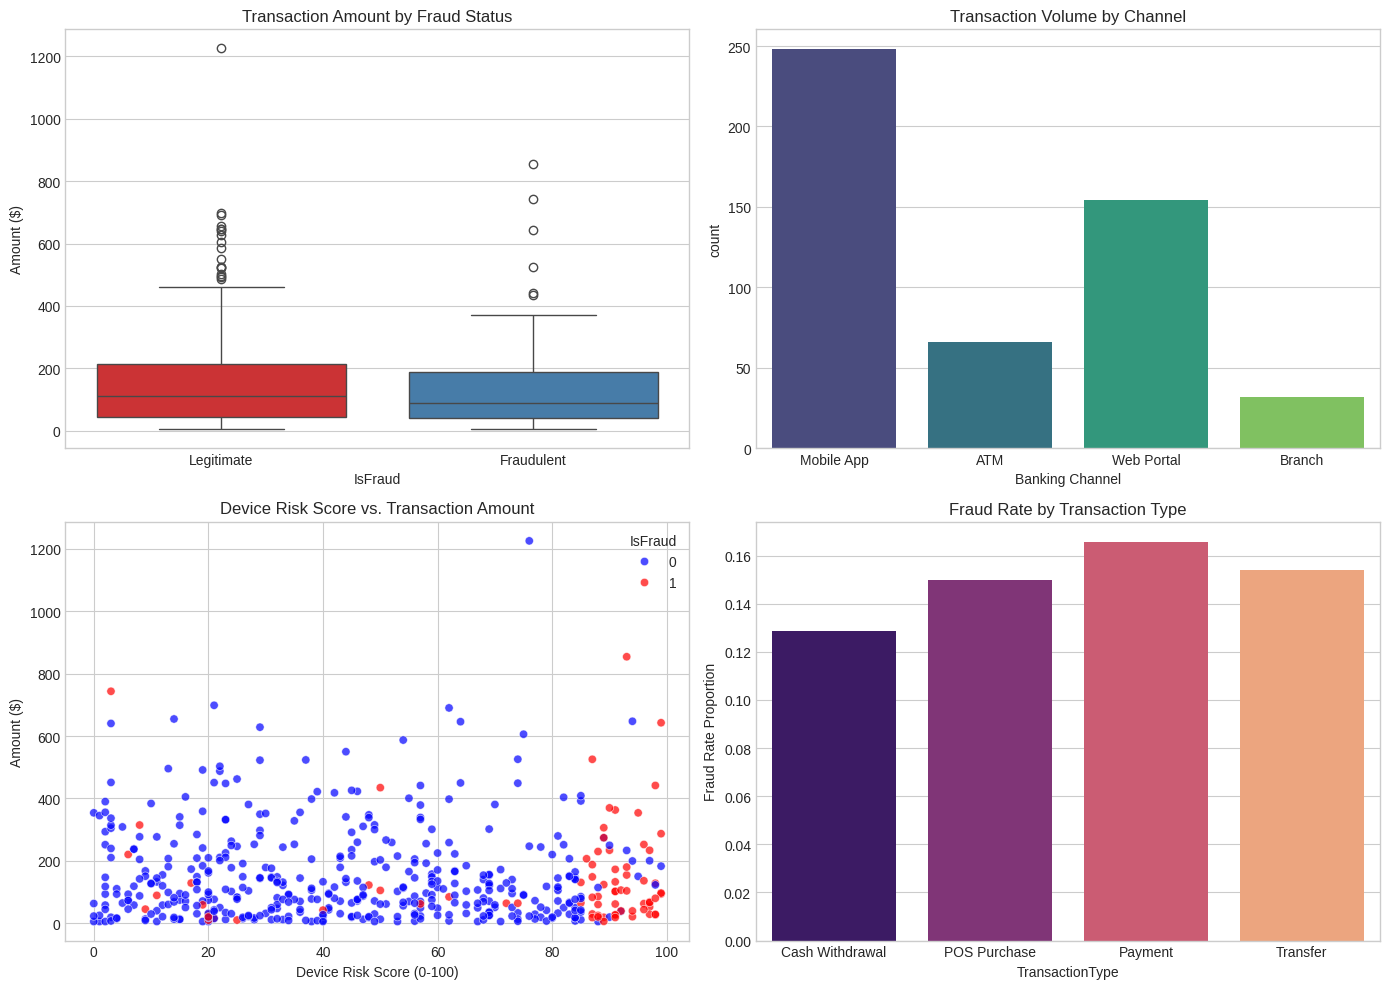

In [5]:
def generate_banking_plots(df):
    """Generates a 4-panel exploratory visualization dashboard without syntax warnings."""
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # Plot 1: Transaction Amount by Fraud Flag
    sns.boxplot(data=df, x='IsFraud', y='Amount', ax=axes[0, 0],
                hue='IsFraud', palette='Set1', legend=False)
    axes[0, 0].set_title('Transaction Amount by Fraud Status')
    axes[0, 0].set_xticks([0, 1])
    axes[0, 0].set_xticklabels(['Legitimate', 'Fraudulent'])
    axes[0, 0].set_ylabel('Amount ($)')

    # Plot 2: Transaction Volume by Channel
    sns.countplot(data=df, x='Channel', ax=axes[0, 1],
                  hue='Channel', palette='viridis', legend=False)
    axes[0, 1].set_title('Transaction Volume by Channel')
    axes[0, 1].set_xlabel('Banking Channel')

    # Plot 3: Risk Score vs. Amount Scatter
    sns.scatterplot(data=df, x='DeviceRiskScore', y='Amount', hue='IsFraud',
                    palette={0: 'blue', 1: 'red'}, ax=axes[1, 0], alpha=0.7)
    axes[1, 0].set_title('Device Risk Score vs. Transaction Amount')
    axes[1, 0].set_xlabel('Device Risk Score (0-100)')
    axes[1, 0].set_ylabel('Amount ($)')

    # Plot 4: Fraud Proportion by Transaction Type
    fraud_by_type = df.groupby('TransactionType')['IsFraud'].mean().reset_index()
    sns.barplot(data=fraud_by_type, x='TransactionType', y='IsFraud', ax=axes[1, 1],
                hue='TransactionType', palette='magma', legend=False)
    axes[1, 1].set_title('Fraud Rate by Transaction Type')
    axes[1, 1].set_ylabel('Fraud Rate Proportion')

    plt.tight_layout()
    plt.show()

generate_banking_plots(df_raw)

            FRAUD DETECTION MODEL EVALUATION                     
Model Accuracy Score: 92.00%

Classification Report:
              precision    recall  f1-score   support

  Legitimate       0.94      0.96      0.95        85
  Fraudulent       0.77      0.67      0.71        15

    accuracy                           0.92       100
   macro avg       0.86      0.82      0.83       100
weighted avg       0.92      0.92      0.92       100




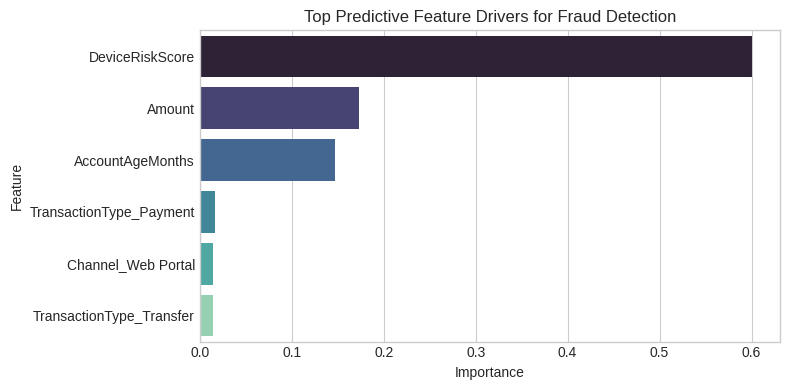

In [6]:
ignore_cols = ['TransactionID', 'AccountID', 'IsFraud']
feature_cols = [col for col in df_processed.columns if col not in ignore_cols]

X = df_processed[feature_cols]
y = df_processed['IsFraud']

# Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Model Training
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

# Predictions and Performance Metrics
y_pred = clf.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print("=================================================================")
print("            FRAUD DETECTION MODEL EVALUATION                     ")
print("=================================================================")
print(f"Model Accuracy Score: {acc * 100:.2f}%\n")
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Legitimate', 'Fraudulent']))
print("=================================================================\n")

# Feature Importance Breakdown
importances = clf.feature_importances_
feature_imp_df = pd.DataFrame({'Feature': feature_cols, 'Importance': importances}).sort_values('Importance', ascending=False)

plt.figure(figsize=(8, 4))
sns.barplot(
    data=feature_imp_df.head(6),
    x='Importance',
    y='Feature',
    hue='Feature',
    palette='mako',
    legend=False
)
plt.title('Top Predictive Feature Drivers for Fraud Detection')
plt.tight_layout()
plt.show()

In [7]:
export_filename = "Banking_Transaction_Analytics_Report.csv"
df_raw.to_csv(export_filename, index=False)
print(f"[INFO] Summary dataset created: {export_filename}")

# Automatic file download trigger in Colab
files.download(export_filename)

[INFO] Summary dataset created: Banking_Transaction_Analytics_Report.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>